In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anairamcosta/country-timeseries")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'country-timeseries' dataset.
Path to dataset files: /kaggle/input/country-timeseries


In [ ]:

import os
df = pd.read_csv(os.path.join(path, "country_timeseries.csv"))

In [ ]:
#Ordino le date dei casi dai più vecchi
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')
df.head()

,Date,Day,Cases_Guinea,Cases_Liberia,Cases_SierraLeone,Cases_Nigeria,Cases_Senegal,Cases_UnitedStates,Cases_Spain,Cases_Mali,Deaths_Guinea,Deaths_Liberia,Deaths_SierraLeone,Deaths_Nigeria,Deaths_Senegal,Deaths_UnitedStates,Deaths_Spain,Deaths_Mali
121,2014-03-22,0,49.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,2014-03-24,2,86.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119,2014-03-25,3,86.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
118,2014-03-26,4,86.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
117,2014-03-27,5,103.0,8.0,6.0,NaN,NaN,NaN,NaN,NaN,66.0,6.0,5.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Scelgo un paese e ricavo i nuovi casi giornalieri
country = "Guinea"
df_seir_Gu = df [['Date', f'Cases_{country}', f'Deaths_{country}']].copy()
df_seir_Gu = df_seir_Gu.dropna()
df_seir_Gu["New_cases"] = df_seir_Gu["Cases_Guinea"].diff().fillna(0)

df_seir_Gu.head()

,Date,Cases_Guinea,Deaths_Guinea,New_cases
121,2014-03-22,49.0,29.0,0.0
120,2014-03-24,86.0,59.0,37.0
119,2014-03-25,86.0,60.0,0.0
118,2014-03-26,86.0,62.0,0.0
117,2014-03-27,103.0,66.0,17.0


Definisco equazioni SEIR:

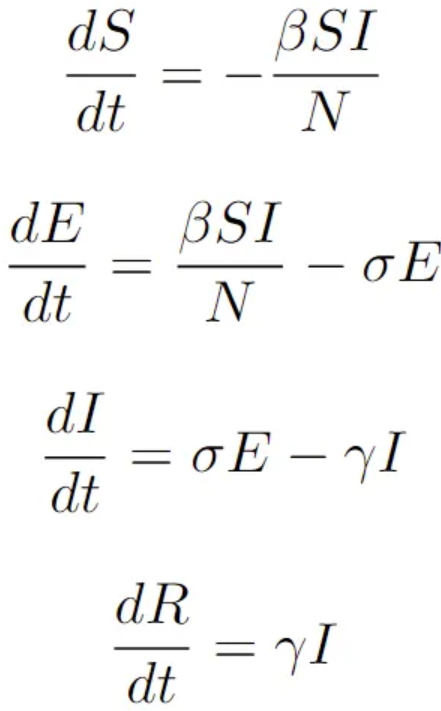



In [ ]:
#Definisce le ODE del sistema e fisso le condizioni iniziali, i parametri beta, gamma, sigma
#li fisso inizialmente

from scipy.integrate import odeint
import matplotlib.pyplot as plt
N = 10000000    #Popolazione
beta  = 0.17    #tasso di trasmissione
sigma = 0.19    #incubazione 5.5 giorni
gamma = 0.1     #tempo infettivo di 10 giorni
f = 0.4         #mortalità

#Condizioni iniziali
I0 = 49
I_data = df_seir_Gu["Cases_Guinea"].values
t_cal = np.arange(len(I_data))  #tempo su cui calibro il modello
t_model = np.linspace(0, 1000, 1001)  #tempo su cui valuto le previsioni
E0 = (gamma/sigma)*I0 #Esposti ma non ancora contagiosi e asintomatici
R0 = 0
S0 = N -I0-R0-E0
y0 = S0, E0, I0, R0,


def seir_model(y, t, N, beta, sigma, gamma):
    S, E, I,  R = y
    dSdt =  -(beta*S*I)/N
    dEdt = (beta*S*I)/N -sigma*E
    dIdt = sigma*E -gamma*I
    dRdt = (1-f)*gamma*I
    return dSdt, dEdt, dIdt,  dRdt

ret = odeint(seir_model, y0, t_cal, args=(N, beta, sigma, gamma))
S, E, I,R = ret.T


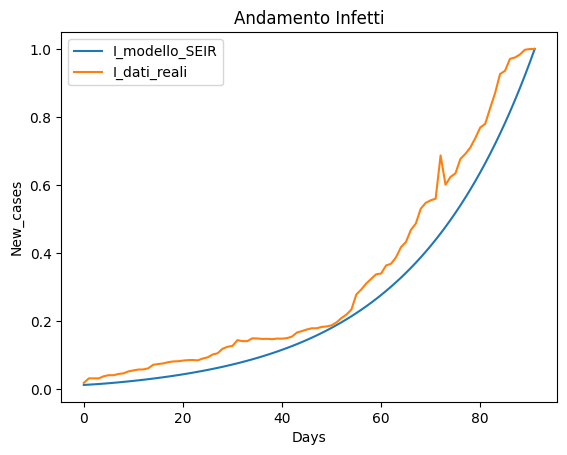

In [ ]:
plt.plot(t_cal, (I+R)/max(I+R), label='I_modello_SEIR')
plt.plot(t_cal,I_data/max(I_data),label='I_dati_reali')
plt.xlabel('Days')
plt.ylabel('New_cases')
plt.title('Andamento Infetti')
plt.legend()
plt.show()

In [ ]:
pip install emcee

In [ ]:
##Definisco Likelihood
from scipy.stats import poisson

def log_likelihood(params):
  beta, sigma, gamma = params
  I_model = I+R
  return np.sum(poisson.logpmf(I_data, I_model))

In [ ]:
#Definisco Prior, non uso un prior uniforme
#considero più probabili i valori che si trovano in letteratura

from scipy.stats import norm

def log_prior(params):
  beta, sigma, gamma = params
  if beta < 0 or sigma < 0 or gamma < 0:
    return -np.inf
  lp = (
      norm.logpdf(beta, loc=0.17, scale=0.2) +
      norm.logpdf(sigma, loc=0.19, scale=0.05) +
      norm.logpdf(gamma, loc=0.1, scale=0.05)
  )


  return lp

In [ ]:
#  Calcolo posterior
def log_posterior(params):
  lp = log_prior(params)
  if not np.isfinite(lp):
    return -np.inf
  return lp + log_likelihood(params)

In [ ]:
import emcee
ndim = 3 # parametri
nwalkers = 20 # numero di catene MCMC
p0 = np.array([0.17, 0.19, 0.1]) + 1e-8 * np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
sampler.run_mcmc(p0,3000)
samples = sampler.get_chain(flat = True)


In [ ]:
beta_sample = samples[:,0]
sigma_sample = samples[:,1]
gamma_sample = samples[:,2]
beta_mean = np.mean(beta_sample)
sigma_mean = np.mean(sigma_sample)
gamma_mean = np.mean(gamma_sample)
beta_cri = np.percentile(beta_sample, [2.5,97.5])
sigma_cri = np.percentile(sigma_sample, [2.5,97.5])
gamma_cri = np.percentile(gamma_sample, [2.5,97.5])
print("Parametri modello SEIR:")
print("beta",beta_mean ,beta_cri, "95%CrI")
print("sigma",sigma_mean,sigma_cri,"95%CrI")
print("gamma",gamma_mean,gamma_cri,"95%CrI")
print("R0 =",beta_mean/gamma_mean)

Parametri modello SEIR:
beta 0.11023705747171361 [0.09698473 0.1720863 ] 95%CrI
sigma 0.4908928472646376 [0.18999473 0.58707487] 95%CrI
gamma 0.06657652116915039 [0.05535332 0.11398229] 95%CrI
R0 = 1.6557947987644965


In [ ]:
#Uso i parametri ottimizzati del modello per fare una previsione
ret_bayes = odeint(seir_model, y0, t_model, args=(N, beta_mean, sigma_mean, gamma_mean))
S_bayes, E_bayes, I_bayes, R_bayes = ret_bayes.T
#valuto bontà del modello
from sklearn.metrics import r2_score

# Calcolo R2 con i risultati del modello ottimizzato
r2 = r2_score(I_data, (I_bayes[:len(I_data)] + R_bayes[:len(I_data)]))


R2 = 0.9763463866165178


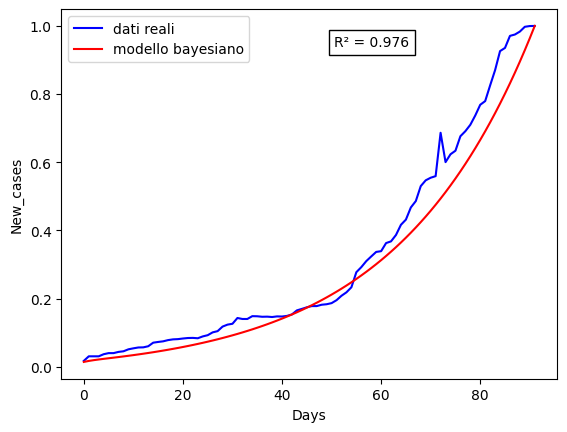

In [ ]:
plt.plot(t_cal,I_data/max(I_data),label='dati reali',color= 'blue')
plt.plot(t_cal,((I_bayes+R_bayes)[:len(I_data)])/max((I_bayes+R_bayes)[:len(I_data)]),label='modello bayesiano',color= 'red')
plt.text(
0.55, 0.90,
f'R² = {r2:.3f}',
transform=plt.gca().transAxes,
bbox=dict(facecolor='white', edgecolor='black')
)
plt.xlabel('Days')
plt.ylabel('New_cases')
plt.legend()
plt.show()

media residui = -55.13954603870411


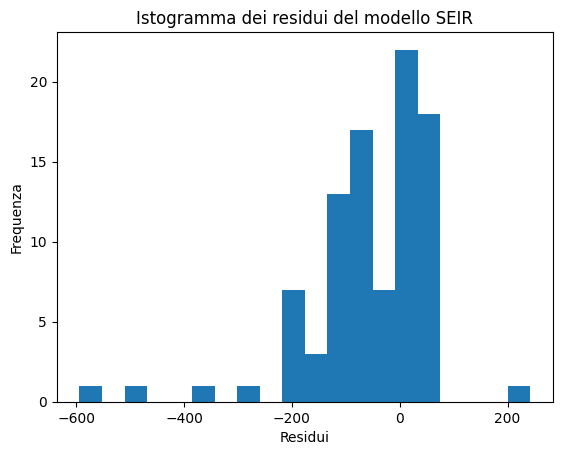

In [ ]:
residui = I_data - (I_bayes[:len(I_data)] + R_bayes[:len(I_data)])
print("media residui =", np.mean(residui))
plt.hist(residui, bins=20)
plt.xlabel('Residui')
plt.ylabel('Frequenza')
plt.title('Istogramma dei residui del modello SEIR')
plt.show()

In [ ]:
rmse = np.sqrt(np.mean(residui**2))
nmrse = rmse / np.max(I_data)
print("RMSE =", rmse)
print("NRMSE =", nmrse)
print("picco I", max(I_data))

RMSE = 127.6165516816857
NRMSE = 0.045971380288791684
picco I 2776.0


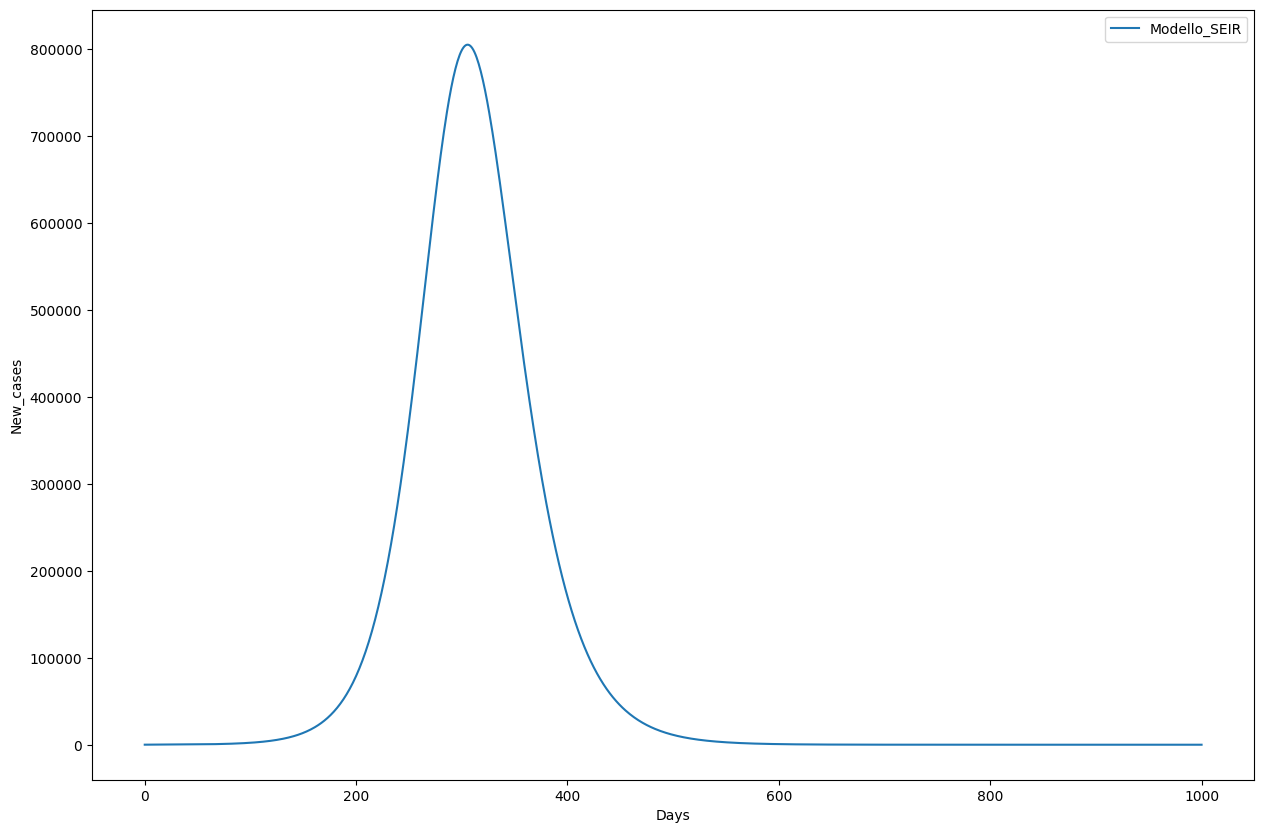

In [ ]:
plt.figure(figsize=(15, 10))
plt.plot(t_model, I_bayes, label='Modello_SEIR')
plt.xlabel('Days')
plt.ylabel('New_cases')
plt.legend()
plt.show()


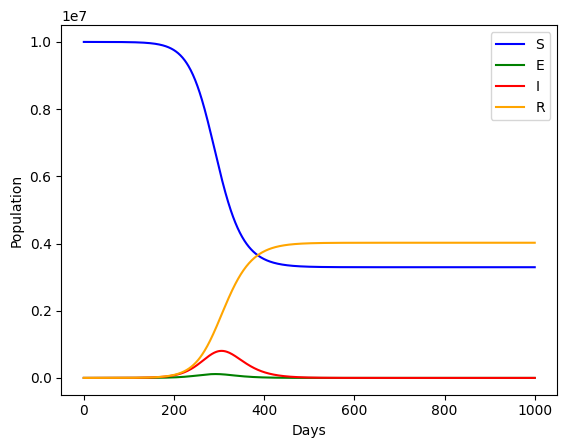

In [ ]:
plt.plot(t_model, S_bayes, label='S', color = "blue")
plt.plot(t_model, E_bayes, label='E', color = "green")
plt.plot(t_model, I_bayes, label='I', color ="red")
plt.plot(t_model, R_bayes, label='R', color = "orange")
plt.xlabel('Days')
plt.ylabel('Population')
plt.legend()
plt.show()

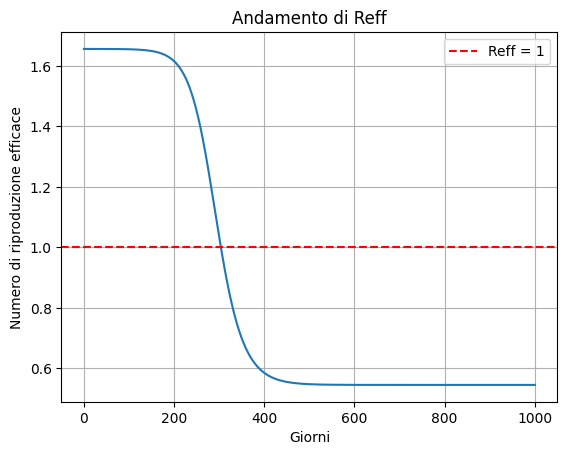

In [ ]:
#Calcolo numero di riproduzione
Reff = (beta_mean / gamma_mean)*S_bayes/N
plt.plot(t, Reff)
plt.axhline(y=1, color='r', linestyle='--', label='Reff = 1')
plt.xlabel('Giorni')
plt.ylabel('Numero di riproduzione efficace')
plt.title('Andamento di Reff')
plt.legend()
plt.grid(True)
plt.show()